# Modelling: negative binomial of cases on lagged climate × elevation

Monthly counts are overdispersed and zero-heavy, so we use a **negative binomial** (not Poisson), pooled across all 77 districts, with a **climate × elevation-band interaction** so the climate response can differ by altitude. Predictors are the dominant lags from the lag analysis (rainfall & min-temp at 2 months, humidity at 1); calendar month absorbs the shared seasonal shape.

Validation is out-of-sample: **fit on 2022–2023, predict 2024**. The climate standardisation is fit on the training years only, so 2024 never leaks in. A **calendar-only baseline** (month + band) tests whether climate adds value. No population offset (none available), so coefficients describe expected case *counts*, not per-capita incidence.

All logic lives in `dengue_climate.analysis.models`.

In [1]:
import dengue_climate.analysis.models as M

train, test = M.split(M.build_frame())
train_s, test_s, mu, sigma = M.standardize(train, test)

full = M.fit(train_s, M._FULL_FORMULA)
base = M.fit(train_s, M._BASELINE_FORMULA)
print(f'train {len(train_s)} rows (2022-23) | test {len(test_s)} rows (2024)')
print('converged:', full.mle_retvals['converged'], base.mle_retvals['converged'])

train 1694 rows (2022-23) | test 924 rows (2024)
converged: True True


/Users/ram/Documents/Academic/Semster-I/DA/Assignments/dengue-climate-nepal/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3375: RuntimeWarning: overflow encountered in scalar divide
  size = 1/alpha * mu**Q
/Users/ram/Documents/Academic/Semster-I/DA/Assignments/dengue-climate-nepal/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3455: RuntimeWarning: overflow encountered in scalar divide
  a1 = 1/alpha * mu**Q
/Users/ram/Documents/Academic/Semster-I/DA/Assignments/dengue-climate-nepal/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3471: RuntimeWarning: overflow encountered in scalar power
  da1 = -alpha**-2


## 1. Incidence-rate ratios

`IRR = exp(coef)`: the multiplicative change in expected cases per **one training-SD** rise in a climate predictor, or per category for the factors. The interaction rows are what differ by elevation.

In [2]:
print('1 SD in original units:', {c: round(sigma[c], 1) for c in M.CLIMATE_PREDICTORS})
irrs = M.irr_table(full)
irrs

1 SD in original units: {'precip_lag2': np.float64(136.5), 'temp_min_lag2': np.float64(8.6), 'humidity_lag1': np.float64(16.7)}


,irr,ci_low,ci_high,p_value
Intercept,1.318,0.727,2.390,0.363
"C(elevation_band, Treatment('Terai'))[T.Hill]",2.137,1.336,3.418,0.002
"C(elevation_band, Treatment('Terai'))[T.Mountain]",1.330,0.713,2.481,0.369
C(month)[T.2],2.057,1.037,4.082,0.039
C(month)[T.3],2.040,1.056,3.942,0.034
C(month)[T.4],1.678,0.890,3.162,0.110
C(month)[T.5],1.071,0.546,2.099,0.842
C(month)[T.6],2.664,1.418,5.005,0.002
C(month)[T.7],7.955,4.117,15.369,0.000
C(month)[T.8],9.201,3.916,21.621,0.000


**The elevation story (RQ2).** Warmth is the dominant driver and its pull *weakens with altitude*: a 1-SD rise in min-temperature multiplies expected cases ~5.8× in the Terai, but the mountain interaction (IRR ≈ 0.20) cuts that sharply — high-altitude cold still caps transmission. **Rainfall runs the other way**: its effect is flat/negative in the Terai (already wet) but the Hill and Mountain interactions (IRR ≈ 1.7–1.9) make rain *more* important higher up. Together that is the upward-suitability signal — temperature gates the mountains, and where it doesn't, rainfall increasingly matters.

## 2. Out-of-sample validation: predict 2024

National monthly cases — actual vs the climate model vs the calendar baseline. The test year was never seen in training.

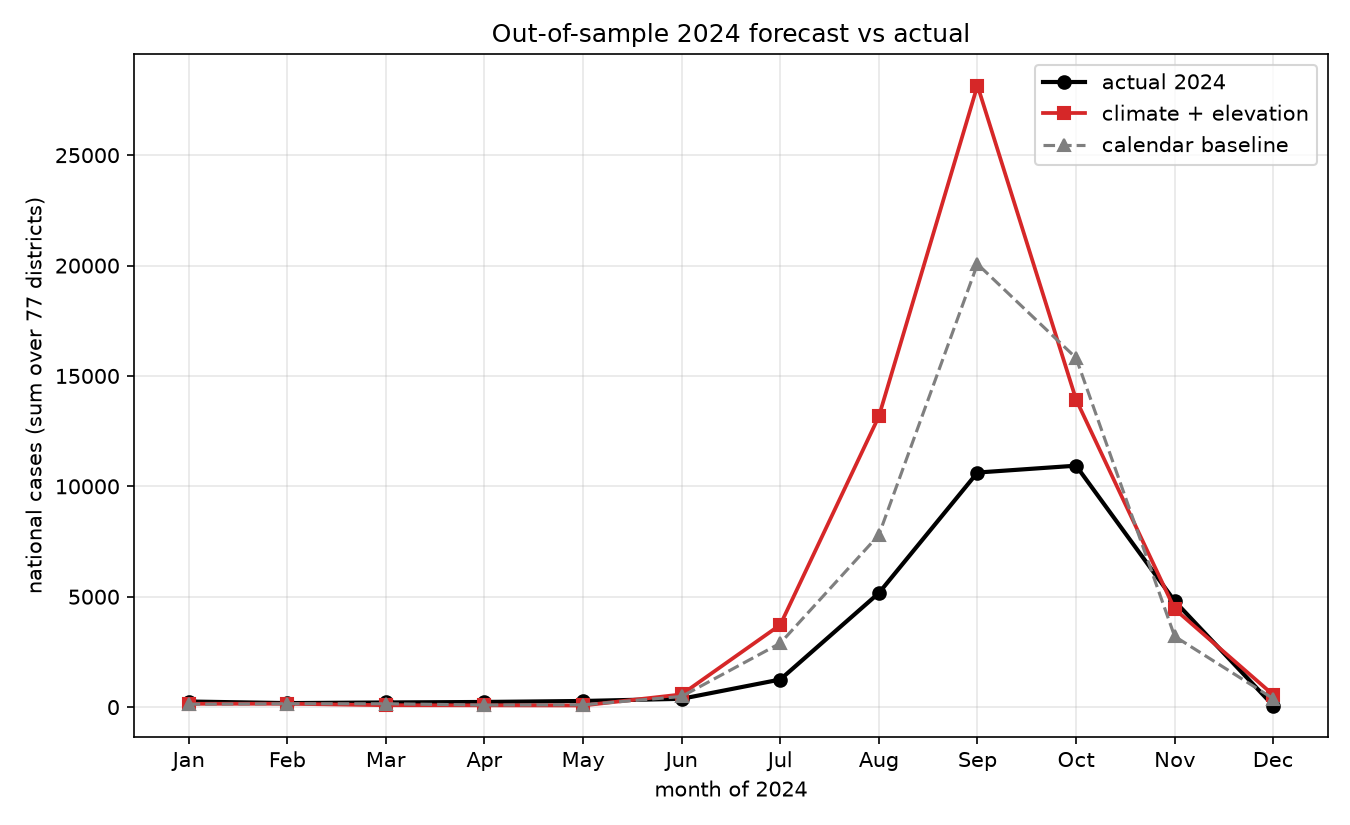

In [3]:
from IPython.display import Image
from dengue_climate.config import get_path

monthly = M.monthly_2024(test_s, full, base)
fig_path = M.plot_predicted_vs_actual(monthly, get_path('figures') / 'predicted_vs_actual_2024.png')
Image(str(fig_path))

In [4]:
import pandas as pd

rows = {
    'climate + elevation': {**M.evaluate(full, test_s), 'aic_insample': full.aic},
    'calendar baseline':   {**M.evaluate(base, test_s), 'aic_insample': base.aic},
}
pd.DataFrame(rows).T.round(2)

,mae,rmse,aic_insample
climate + elevation,70.79,197.95,10430.98
calendar baseline,61.53,191.97,10547.25


**Honest read.** Climate clearly improves *in-sample* fit (lower AIC), and the interaction structure above is significant and interpretable. But **out-of-sample it does not beat the calendar**: 2024 was a much smaller season than 2022–2023, so both models over-forecast the September peak and the richer climate model over-forecasts it more. With only three years, the panel's power lives in the 77 districts, not in anticipating a low-incidence year — exactly the limitation to state plainly in the write-up. The value here is **explanatory** (how the climate–dengue link bends with elevation), not a production forecaster.